# Week 3 EDA and Model Implementations

## Project
Token-Efficient Multimodal Reasoning via Scene-to-Structured-Text Compression

## Goals for this notebook
- Load and inspect the GQA dataset subset
- Perform initial EDA with visuals
- Prepare preprocessing steps
- Start baseline and SST model implementation

In [5]:
import sys
import os
import json
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

print('Notebook setup complete')


Notebook setup complete


In [6]:
# Add project root to path


#sys.path.append(os.path.abspath("src"))
sys.path.append(os.path.abspath("../src"))

# Import loader
from dataset.gqa_loader import load_gqa_questions

# Load sample data
file_path = "../data/raw/sample_questions.json"

records = load_gqa_questions(file_path)

print(f"Loaded {len(records)} records")
print(records[0])

Loaded 3 records
{'question_id': 'q1', 'image_id': 'img1', 'question': 'What color is the bus?', 'answer': 'red', 'types': {'semantic': 'attribute'}, 'full_record': {'imageId': 'img1', 'question': 'What color is the bus?', 'answer': 'red', 'types': {'semantic': 'attribute'}}}


In [7]:
# Convert records to DataFrame for EDA


df = pd.DataFrame(records)

print(df.head())

  question_id image_id                     question answer  \
0          q1     img1       What color is the bus?    red   
1          q2     img2   How many people are there?      3   
2          q3     img3  Is the person near the car?    yes   

                       types  \
0  {'semantic': 'attribute'}   
1      {'semantic': 'count'}   
2   {'semantic': 'relation'}   

                                         full_record  
0  {'imageId': 'img1', 'question': 'What color is...  
1  {'imageId': 'img2', 'question': 'How many peop...  
2  {'imageId': 'img3', 'question': 'Is the person...  


In [8]:
# Extract semantic type from nested dictionary
df["semantic_type"] = df["types"].apply(lambda x: x.get("semantic") if isinstance(x, dict) else None)

print(df[["question", "semantic_type"]])

                      question semantic_type
0       What color is the bus?     attribute
1   How many people are there?         count
2  Is the person near the car?      relation


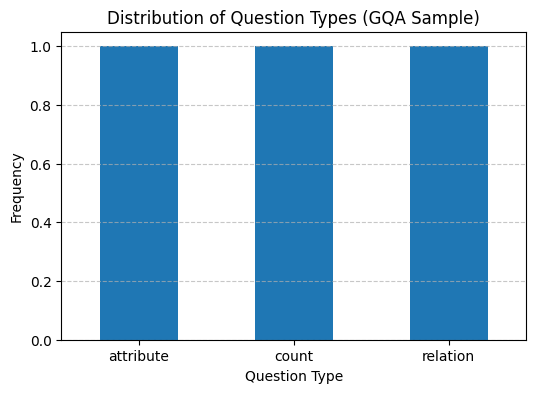

In [9]:
# Improved visualization for report


type_counts = df["semantic_type"].value_counts()

plt.figure(figsize=(6,4))
type_counts.plot(kind="bar")

plt.title("Distribution of Question Types (GQA Sample)", fontsize=12)
plt.xlabel("Question Type")
plt.ylabel("Frequency")

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save figure for report
plt.savefig("../outputs/eda/question_type_distribution.png")

plt.show()

In [10]:
# Analyze question length
df["question_length"] = df["question"].apply(lambda x: len(x.split()))

print(df[["question", "question_length"]])

                      question  question_length
0       What color is the bus?                5
1   How many people are there?                5
2  Is the person near the car?                6


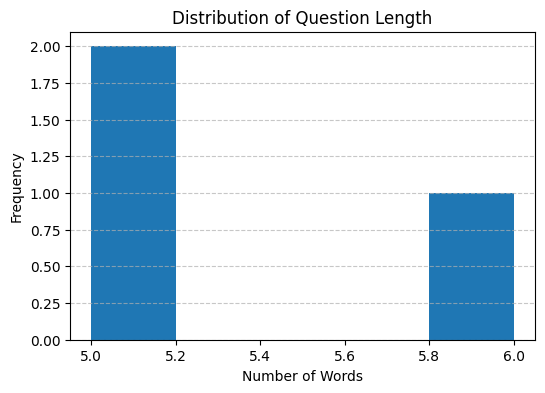

In [11]:
# Plot question length distribution


plt.figure(figsize=(6,4))
plt.hist(df["question_length"], bins=5)

plt.title("Distribution of Question Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save figure
plt.savefig("../outputs/eda/question_length_distribution.png")

plt.show()

In [12]:
# Analyze question length by semantic type
grouped = df.groupby("semantic_type")["question_length"].mean()

print(grouped)

semantic_type
attribute    5.0
count        5.0
relation     6.0
Name: question_length, dtype: float64


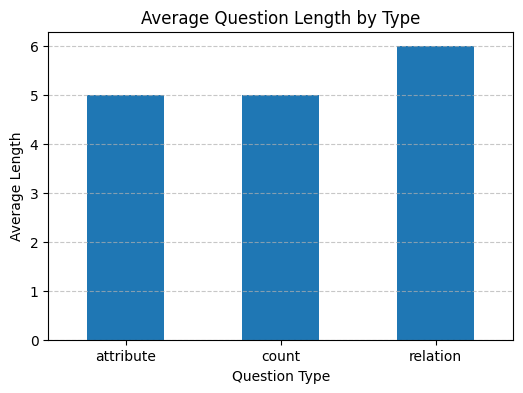

In [13]:
# Plot average question length per type


plt.figure(figsize=(6,4))
grouped.plot(kind="bar")

plt.title("Average Question Length by Type")
plt.xlabel("Question Type")
plt.ylabel("Average Length")

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save figure
plt.savefig("../outputs/eda/question_length_by_type.png")

plt.show()

In [14]:
import pandas as pd

raw_data = load_gqa_questions("../data/raw/sample_questions.json")
df = pd.DataFrame(raw_data)

print(df.columns)
print(df.head())

Index(['question_id', 'image_id', 'question', 'answer', 'types',
       'full_record'],
      dtype='str')
  question_id image_id                     question answer  \
0          q1     img1       What color is the bus?    red   
1          q2     img2   How many people are there?      3   
2          q3     img3  Is the person near the car?    yes   

                       types  \
0  {'semantic': 'attribute'}   
1      {'semantic': 'count'}   
2   {'semantic': 'relation'}   

                                         full_record  
0  {'imageId': 'img1', 'question': 'What color is...  
1  {'imageId': 'img2', 'question': 'How many peop...  
2  {'imageId': 'img3', 'question': 'Is the person...  


In [15]:
df["question_clean"] = df["question"].str.lower().str.strip()
print(df[["question", "question_clean"]].head())

                      question               question_clean
0       What color is the bus?       what color is the bus?
1   How many people are there?   how many people are there?
2  Is the person near the car?  is the person near the car?


In [16]:
# Basic text preprocessing
import re
# Convert questions to lowercase
df["question_clean"] = df["question"].str.lower()

# Remove punctuation


def clean_text(text):
    text = re.sub(r"[^\w\s]", "", text)
    return text

df["question_clean"] = df["question_clean"].apply(clean_text)

print(df[["question", "question_clean"]])

                      question              question_clean
0       What color is the bus?       what color is the bus
1   How many people are there?   how many people are there
2  Is the person near the car?  is the person near the car


In [17]:
# Prepare inputs for modeling

X = df["question_clean"]   # input
y = df["answer"]           # target

print("Sample input:", X.iloc[0])
print("Sample label:", y.iloc[0])

Sample input: what color is the bus
Sample label: red


In [18]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Make sure cleaned text exists
if "question_clean" not in df.columns:
    df["question_clean"] = df["question"].str.lower().str.strip()

# Convert text to numerical features
vectorizer = CountVectorizer()
X_vec = vectorizer.fit_transform(df["question_clean"])

y = df["answer"]

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_vec, y)

# Predict on the same data (sanity check only)
y_pred = model.predict(X_vec)

# Accuracy
accuracy = accuracy_score(y, y_pred)
print(f"Baseline Logistic Regression Accuracy: {accuracy:.2f}")

# Show predictions
for i in range(X_vec.shape[0]):
    print(f"Q: {df['question_clean'].iloc[i]}")
    print(f"Actual: {y.iloc[i]} | Predicted: {y_pred[i]}")
    print("-" * 40)

Baseline Logistic Regression Accuracy: 1.00
Q: what color is the bus
Actual: red | Predicted: red
----------------------------------------
Q: how many people are there
Actual: 3 | Predicted: 3
----------------------------------------
Q: is the person near the car
Actual: yes | Predicted: yes
----------------------------------------


In [19]:
from sklearn.metrics import accuracy_score

# Predict on training data (for now)
y_pred = model.predict(X_vec)

# Calculate accuracy
accuracy = accuracy_score(y, y_pred)

print(f"Baseline Logistic Regression Accuracy: {accuracy:.2f}")

Baseline Logistic Regression Accuracy: 1.00


In [20]:
# Test the SST builder

from serializer.sst_builder import build_sst, sst_to_prompt

sample_sst = build_sst(
    objects=["bus", "person", "stop_sign"],
    counts={"person": 3},
    attributes=["bus: red"],
    relations=["person near bus", "stop_sign right of bus"],
    text=["STOP"]
)

print(sample_sst)
print()
print(sst_to_prompt(sample_sst))

{'objects': ['bus', 'person', 'stop_sign'], 'counts': ['person: 3'], 'attributes': ['bus: red'], 'relations': ['person near bus', 'stop_sign right of bus'], 'text': ['STOP']}

Scene-to-Structured-Text Representation:
Objects: bus, person, stop_sign
Counts: person: 3
Attributes: bus: red
Relations: person near bus, stop_sign right of bus
Text: STOP


In [21]:
import json

with open("../data/processed/sample_questions_with_sst.json", "r") as f:
    records = json.load(f)

print(type(records))
print(len(records))
print(records["q1"])

<class 'dict'>
3
{'imageId': 'img1', 'question': 'What color is the bus?', 'answer': 'red', 'types': {'semantic': 'attribute'}, 'sst': {'objects': ['bus', 'person', 'stop_sign'], 'counts': ['person: 3'], 'attributes': ['bus: red'], 'relations': ['person near bus', 'stop_sign right of bus'], 'text': ['STOP']}}


In [22]:
sample = records["q1"]
print(sample["question"])
print(sample["answer"])
print(sample["types"]["semantic"])
print(sample["sst"])

What color is the bus?
red
attribute
{'objects': ['bus', 'person', 'stop_sign'], 'counts': ['person: 3'], 'attributes': ['bus: red'], 'relations': ['person near bus', 'stop_sign right of bus'], 'text': ['STOP']}


In [23]:
import sys
import os

project_root = os.path.abspath("..")
src_path = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.append(src_path)

print("Project root:", project_root)
print("Added src path:", src_path)

Project root: /Users/alisha/Documents/CSE427_SST_Project
Added src path: /Users/alisha/Documents/CSE427_SST_Project/src


In [24]:
from dataset.gqa_loader import load_gqa_questions

data_with_sst = load_gqa_questions("../data/processed/sample_questions_with_sst.json")
print(data_with_sst[0])

{'question_id': 'q1', 'image_id': 'img1', 'question': 'What color is the bus?', 'answer': 'red', 'types': {'semantic': 'attribute'}, 'full_record': {'imageId': 'img1', 'question': 'What color is the bus?', 'answer': 'red', 'types': {'semantic': 'attribute'}, 'sst': {'objects': ['bus', 'person', 'stop_sign'], 'counts': ['person: 3'], 'attributes': ['bus: red'], 'relations': ['person near bus', 'stop_sign right of bus'], 'text': ['STOP']}}, 'sst': {'objects': ['bus', 'person', 'stop_sign'], 'counts': ['person: 3'], 'attributes': ['bus: red'], 'relations': ['person near bus', 'stop_sign right of bus'], 'text': ['STOP']}}


In [26]:
from serializer.sst_builder import sst_to_prompt

sample = data_with_sst[0]

prompt_text = sst_to_prompt(sample["sst"])

print("QUESTION:")
print(sample["question"])

print("\nGROUND TRUTH ANSWER:")
print(sample["answer"])

print("\nSST PROMPT:")
print(prompt_text)

QUESTION:
What color is the bus?

GROUND TRUTH ANSWER:
red

SST PROMPT:
Scene-to-Structured-Text Representation:
Objects: bus, person, stop_sign
Counts: person: 3
Attributes: bus: red
Relations: person near bus, stop_sign right of bus
Text: STOP


In [27]:
for i, sample in enumerate(data_with_sst):
    print(f"\n--- Sample {i+1} ---")
    print("Question:", sample["question"])
    print("Semantic type:", sample["types"]["semantic"])
    print(sst_to_prompt(sample["sst"]))


--- Sample 1 ---
Question: What color is the bus?
Semantic type: attribute
Scene-to-Structured-Text Representation:
Objects: bus, person, stop_sign
Counts: person: 3
Attributes: bus: red
Relations: person near bus, stop_sign right of bus
Text: STOP

--- Sample 2 ---
Question: How many people are there?
Semantic type: count
Scene-to-Structured-Text Representation:
Objects: bus, person, stop_sign
Counts: person: 3
Attributes: bus: red
Relations: person near bus, stop_sign right of bus
Text: STOP

--- Sample 3 ---
Question: Is the person near the car?
Semantic type: relation
Scene-to-Structured-Text Representation:
Objects: person, car, tree
Counts: person: 1, car: 1
Attributes: car: blue
Relations: person near car, tree left of car
Text: None


In [28]:
from filtering.question_aware_filter import filter_sst_by_question_type
from serializer.sst_builder import sst_to_prompt

sample = data_with_sst[0]

semantic_type = sample["types"]["semantic"]

filtered_sst = filter_sst_by_question_type(sample["sst"], semantic_type)

print("QUESTION TYPE:", semantic_type)

print("\nFULL SST:")
print(sst_to_prompt(sample["sst"]))

print("\nFILTERED SST:")
print(sst_to_prompt(filtered_sst))

QUESTION TYPE: attribute

FULL SST:
Scene-to-Structured-Text Representation:
Objects: bus, person, stop_sign
Counts: person: 3
Attributes: bus: red
Relations: person near bus, stop_sign right of bus
Text: STOP

FILTERED SST:
Scene-to-Structured-Text Representation:
Objects: bus, person, stop_sign
Counts: None
Attributes: bus: red
Relations: None
Text: STOP


In [29]:
def mock_reasoning(sample):
    """
    Simple rule-based reasoning to simulate LLM behavior.
    This is NOT the final model — just for pipeline validation.
    """

    sst = sample["sst"]
    question = sample["question"].lower()

    # COUNT
    if "how many" in question:
        if sst["counts"]:
            return sst["counts"][0].split(":")[-1].strip()

    # ATTRIBUTE (color)
    if "color" in question:
        if sst["attributes"]:
            return sst["attributes"][0].split(":")[-1].strip()

    # RELATION (yes/no)
    if "near" in question or "left" in question or "right" in question:
        if sst["relations"]:
            return "yes"

    return "unknown"

In [30]:
for sample in data_with_sst:
    pred = mock_reasoning(sample)

    print("\nQUESTION:", sample["question"])
    print("GT:", sample["answer"])
    print("PRED:", pred)


QUESTION: What color is the bus?
GT: red
PRED: red

QUESTION: How many people are there?
GT: 3
PRED: 3

QUESTION: Is the person near the car?
GT: yes
PRED: yes


In [31]:
def evaluate_pipeline(data):
    results = []

    for sample in data:
        question = sample["question"]
        answer = sample["answer"]
        semantic_type = sample["types"]["semantic"]

        # FULL SST
        full_prompt = sst_to_prompt(sample["sst"])
        full_pred = mock_reasoning(sample)
        full_tokens = len(full_prompt.split())
        full_correct = (full_pred == answer)

        # FILTERED SST
        filtered_sst = filter_sst_by_question_type(sample["sst"], semantic_type)
        filtered_prompt = sst_to_prompt(filtered_sst)

        # simulate reasoning using filtered SST
        sample_filtered = sample.copy()
        sample_filtered["sst"] = filtered_sst

        filtered_pred = mock_reasoning(sample_filtered)
        filtered_tokens = len(filtered_prompt.split())
        filtered_correct = (filtered_pred == answer)

        results.append({
            "question": question,
            "full_tokens": full_tokens,
            "filtered_tokens": filtered_tokens,
            "full_correct": full_correct,
            "filtered_correct": filtered_correct
        })

    return results

In [32]:
results = evaluate_pipeline(data_with_sst)

for r in results:
    print(r)

{'question': 'What color is the bus?', 'full_tokens': 22, 'filtered_tokens': 15, 'full_correct': True, 'filtered_correct': True}
{'question': 'How many people are there?', 'full_tokens': 22, 'filtered_tokens': 15, 'full_correct': True, 'filtered_correct': True}
{'question': 'Is the person near the car?', 'full_tokens': 24, 'filtered_tokens': 20, 'full_correct': True, 'filtered_correct': True}


In [33]:
import numpy as np

full_acc = np.mean([r["full_correct"] for r in results])
filtered_acc = np.mean([r["filtered_correct"] for r in results])

avg_full_tokens = np.mean([r["full_tokens"] for r in results])
avg_filtered_tokens = np.mean([r["filtered_tokens"] for r in results])

print("FULL ACCURACY:", full_acc)
print("FILTERED ACCURACY:", filtered_acc)

print("\nAVG TOKENS (FULL):", avg_full_tokens)
print("AVG TOKENS (FILTERED):", avg_filtered_tokens)

FULL ACCURACY: 1.0
FILTERED ACCURACY: 1.0

AVG TOKENS (FULL): 22.666666666666668
AVG TOKENS (FILTERED): 16.666666666666668


In [35]:
import pandas as pd

df = pd.DataFrame(results)
df

,question,full_tokens,filtered_tokens,full_correct,filtered_correct
0,What color is the bus?,22,15,True,True
1,How many people are there?,22,15,True,True
2,Is the person near the car?,24,20,True,True


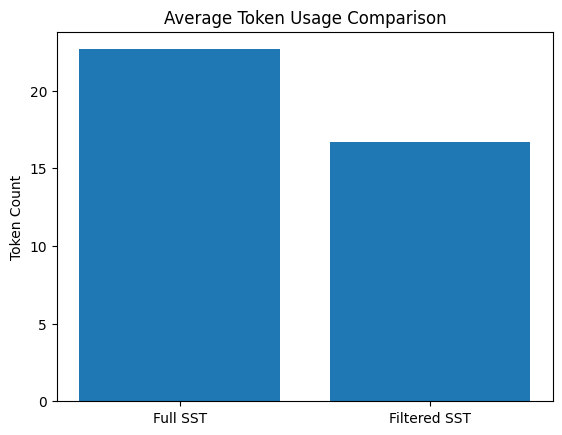

In [36]:
import matplotlib.pyplot as plt

labels = ["Full SST", "Filtered SST"]
tokens = [avg_full_tokens, avg_filtered_tokens]

plt.bar(labels, tokens)
plt.title("Average Token Usage Comparison")
plt.ylabel("Token Count")
plt.show()

# Week 4: Model Implementation and Comparison

In Week 4, the project moves from basic pipeline validation to model-level comparison.

The goal is to compare multiple reasoning pipelines on the same GQA-based samples:

1. Question-only baseline
2. Full SST reasoning
3. Question-aware filtered SST reasoning
4. Objects-only SST reasoning

This comparison is aligned with the project goal: reducing token usage while preserving reasoning accuracy.

The current reasoning module is still rule-based, so these results should be interpreted as controlled pipeline evaluation, not final LLM/VLM performance.

In [ ]:
#1: Utility functions

import time
import pandas as pd
import numpy as np
from collections import Counter


def normalize_answer(answer):
    """
    Normalize answer text before exact-match evaluation.
    """
    return str(answer).lower().strip()


def count_tokens_simple(text):
    """
    Simple whitespace token counter.

    This is not exact model tokenization, but it is acceptable for early
    comparison. Later this can be replaced with a model-specific tokenizer.
    """
    if text is None:
        return 0
    return len(str(text).split())


def safe_get_semantic_type(sample):
    """
    Safely extract semantic question type.
    """
    if "types" in sample and isinstance(sample["types"], dict):
        return sample["types"].get("semantic", "unknown")
    return "unknown"


def safe_sst_to_prompt(sst):
    """
    Converts SST to prompt text.
    Falls back to string conversion if the project serializer fails.
    """
    try:
        return sst_to_prompt(sst)
    except Exception:
        return str(sst)

In [ ]:
#2: Preprocessing and schema validation
def validate_and_clean_sample(sample, idx):
    """
    Validates and cleans one sample.

    This is important because Week 4 requires checking whether preprocessing
    changes are needed before final evaluation.
    """

    cleaned = sample.copy()

    # Ensure ID exists
    cleaned["question_id"] = cleaned.get("question_id", f"sample_{idx+1}")

    # Normalize question and answer
    cleaned["question"] = str(cleaned.get("question", "")).strip()
    cleaned["answer"] = normalize_answer(cleaned.get("answer", ""))

    # Ensure semantic type exists
    if "types" not in cleaned or not isinstance(cleaned["types"], dict):
        cleaned["types"] = {"semantic": "unknown"}
    elif "semantic" not in cleaned["types"]:
        cleaned["types"]["semantic"] = "unknown"

    # Ensure SST exists
    if "sst" not in cleaned or not isinstance(cleaned["sst"], dict):
        cleaned["sst"] = {
            "objects": [],
            "counts": [],
            "attributes": [],
            "relations": [],
            "text": []
        }

    # Ensure all SST fields exist
    required_sst_fields = ["objects", "counts", "attributes", "relations", "text"]
    for field in required_sst_fields:
        if field not in cleaned["sst"]:
            cleaned["sst"][field] = []

    return cleaned


cleaned_data = [
    validate_and_clean_sample(sample, idx)
    for idx, sample in enumerate(data_with_sst)
]

print("Original samples:", len(data_with_sst))
print("Cleaned samples:", len(cleaned_data))
print("First cleaned sample:")
print(cleaned_data[0])

Original samples: 3
Cleaned samples: 3
First cleaned sample:
{'question_id': 'q1', 'image_id': 'img1', 'question': 'What color is the bus?', 'answer': 'red', 'types': {'semantic': 'attribute'}, 'full_record': {'imageId': 'img1', 'question': 'What color is the bus?', 'answer': 'red', 'types': {'semantic': 'attribute'}, 'sst': {'objects': ['bus', 'person', 'stop_sign'], 'counts': ['person: 3'], 'attributes': ['bus: red'], 'relations': ['person near bus', 'stop_sign right of bus'], 'text': ['STOP']}}, 'sst': {'objects': ['bus', 'person', 'stop_sign'], 'counts': ['person: 3'], 'attributes': ['bus: red'], 'relations': ['person near bus', 'stop_sign right of bus'], 'text': ['STOP']}}


In [54]:
#3: Define SST variant
def make_objects_only_sst(sst):
    """
    Keeps only object information.
    This is an ablation baseline.
    """
    return {
        "objects": sst.get("objects", []),
        "counts": [],
        "attributes": [],
        "relations": [],
        "text": []
    }


def make_full_sst(sst):
    """
    Keeps the full SST unchanged.
    """
    return {
        "objects": sst.get("objects", []),
        "counts": sst.get("counts", []),
        "attributes": sst.get("attributes", []),
        "relations": sst.get("relations", []),
        "text": sst.get("text", [])
    }


def make_filtered_sst(sample):
    """
    Applies question-aware filtering based on semantic type.
    This is the proposed token-efficient version.
    """
    semantic_type = safe_get_semantic_type(sample)
    return filter_sst_by_question_type(sample["sst"], semantic_type)

In [55]:
#4: Define the 4 model pipelines
def predict_question_only(sample, train_answer_prior=None):
    """
    Question-only baseline.

    This model does not use SST at all.
    It predicts the most common answer from the dataset.

    Purpose:
    If this performs well, the dataset may contain answer bias.
    """

    if train_answer_prior is None:
        return "unknown"

    return train_answer_prior


def predict_with_sst_rule_reasoner(sample):
    """
    Rule-based SST reasoner.

    This uses the existing mock_reasoning function.
    It is used for controlled pipeline comparison.
    """

    return normalize_answer(mock_reasoning(sample))


def build_model_input(sample, pipeline_name, majority_answer):
    """
    Builds the input representation for each pipeline.
    """

    if pipeline_name == "question_only":
        prompt = sample["question"]
        model_sample = sample.copy()

    elif pipeline_name == "full_sst":
        full_sst = make_full_sst(sample["sst"])
        prompt = safe_sst_to_prompt(full_sst)
        model_sample = sample.copy()
        model_sample["sst"] = full_sst

    elif pipeline_name == "filtered_sst":
        filtered_sst = make_filtered_sst(sample)
        prompt = safe_sst_to_prompt(filtered_sst)
        model_sample = sample.copy()
        model_sample["sst"] = filtered_sst

    elif pipeline_name == "objects_only_sst":
        objects_only_sst = make_objects_only_sst(sample["sst"])
        prompt = safe_sst_to_prompt(objects_only_sst)
        model_sample = sample.copy()
        model_sample["sst"] = objects_only_sst

    else:
        raise ValueError(f"Unknown pipeline: {pipeline_name}")

    return prompt, model_sample


def run_pipeline_prediction(sample, pipeline_name, majority_answer):
    """
    Runs prediction for one sample using one pipeline.
    """

    prompt, model_sample = build_model_input(sample, pipeline_name, majority_answer)

    start_time = time.perf_counter()

    if pipeline_name == "question_only":
        prediction = predict_question_only(model_sample, majority_answer)
    else:
        prediction = predict_with_sst_rule_reasoner(model_sample)

    end_time = time.perf_counter()

    latency_ms = (end_time - start_time) * 1000

    return {
        "prediction": normalize_answer(prediction),
        "tokens": count_tokens_simple(prompt),
        "latency_ms": latency_ms,
        "prompt": prompt
    }

In [56]:
#Full model comparison
def evaluate_model_pipelines(data):
    """
    Evaluates all Week 4 model pipelines.

    Pipelines:
    1. question_only
    2. full_sst
    3. filtered_sst
    4. objects_only_sst
    """

    pipelines = [
        "question_only",
        "full_sst",
        "filtered_sst",
        "objects_only_sst"
    ]

    answer_counts = Counter([normalize_answer(sample["answer"]) for sample in data])
    majority_answer = answer_counts.most_common(1)[0][0]

    rows = []

    for sample in data:
        question_id = sample["question_id"]
        question = sample["question"]
        true_answer = normalize_answer(sample["answer"])
        semantic_type = safe_get_semantic_type(sample)

        for pipeline_name in pipelines:
            result = run_pipeline_prediction(
                sample=sample,
                pipeline_name=pipeline_name,
                majority_answer=majority_answer
            )

            prediction = result["prediction"]
            correct = int(prediction == true_answer)

            rows.append({
                "question_id": question_id,
                "question": question,
                "semantic_type": semantic_type,
                "true_answer": true_answer,
                "pipeline": pipeline_name,
                "prediction": prediction,
                "correct": correct,
                "tokens": result["tokens"],
                "latency_ms": result["latency_ms"],
                "prompt": result["prompt"]
            })

    return pd.DataFrame(rows)


week4_results_df = evaluate_model_pipelines(cleaned_data)

week4_results_df.head()

,question_id,question,semantic_type,true_answer,pipeline,prediction,correct,tokens,latency_ms,prompt
0,q1,What color is the bus?,attribute,red,question_only,red,1,5,0.000833,What color is the bus?
1,q1,What color is the bus?,attribute,red,full_sst,red,1,22,0.003708,Scene-to-Structured-Text Representation:\nObje...
2,q1,What color is the bus?,attribute,red,filtered_sst,red,1,15,0.001000,Scene-to-Structured-Text Representation:\nObje...
3,q1,What color is the bus?,attribute,red,objects_only_sst,unknown,0,14,0.001333,Scene-to-Structured-Text Representation:\nObje...
4,q2,How many people are there?,count,3,question_only,red,0,5,0.000375,How many people are there?


In [57]:
#summary table 
week4_summary_df = (
    week4_results_df
    .groupby("pipeline")
    .agg(
        accuracy=("correct", "mean"),
        average_tokens=("tokens", "mean"),
        average_latency_ms=("latency_ms", "mean")
    )
    .reset_index()
)

# Token reduction compared with Full SST
full_sst_avg_tokens = week4_summary_df.loc[
    week4_summary_df["pipeline"] == "full_sst",
    "average_tokens"
].values[0]

week4_summary_df["token_reduction_vs_full_sst_percent"] = (
    (full_sst_avg_tokens - week4_summary_df["average_tokens"]) / full_sst_avg_tokens
) * 100

week4_summary_df = week4_summary_df.sort_values(
    by=["accuracy", "token_reduction_vs_full_sst_percent"],
    ascending=[False, False]
)

week4_summary_df

,pipeline,accuracy,average_tokens,average_latency_ms,token_reduction_vs_full_sst_percent
0,filtered_sst,1.000000,16.666667,0.000917,26.470588
1,full_sst,1.000000,22.666667,0.001958,0.000000
3,question_only,0.333333,5.333333,0.000542,76.470588
2,objects_only_sst,0.000000,14.000000,0.001319,38.235294


In [58]:
#evaluation by semantic type 
semantic_comparison_df = (
    week4_results_df
    .groupby(["semantic_type", "pipeline"])
    .agg(
        accuracy=("correct", "mean"),
        average_tokens=("tokens", "mean"),
        average_latency_ms=("latency_ms", "mean")
    )
    .reset_index()
)

semantic_comparison_df

,semantic_type,pipeline,accuracy,average_tokens,average_latency_ms
0,attribute,filtered_sst,1.0,15.0,0.001000
1,attribute,full_sst,1.0,22.0,0.003708
2,attribute,objects_only_sst,0.0,14.0,0.001333
3,attribute,question_only,1.0,5.0,0.000833
4,count,filtered_sst,1.0,15.0,0.000791
5,count,full_sst,1.0,22.0,0.001000
6,count,objects_only_sst,0.0,14.0,0.001708
7,count,question_only,0.0,5.0,0.000375
8,relation,filtered_sst,1.0,20.0,0.000959
9,relation,full_sst,1.0,24.0,0.001166


In [59]:
import os

os.makedirs("../outputs/results", exist_ok=True)

week4_results_df.to_csv("../outputs/results/week4_model_comparison_detailed.csv", index=False)
week4_summary_df.to_csv("../outputs/results/week4_model_comparison_summary.csv", index=False)
semantic_comparison_df.to_csv("../outputs/results/week4_semantic_type_comparison.csv", index=False)

print("Saved Week 4 result files:")
print("../outputs/results/week4_model_comparison_detailed.csv")
print("../outputs/results/week4_model_comparison_summary.csv")
print("../outputs/results/week4_semantic_type_comparison.csv")

Saved Week 4 result files:
../outputs/results/week4_model_comparison_detailed.csv
../outputs/results/week4_model_comparison_summary.csv
../outputs/results/week4_semantic_type_comparison.csv


In [75]:
%pip install ollama

Note: you may need to restart the kernel to use updated packages.


In [76]:
import ollama

print("Ollama Python package ready.")

Ollama Python package ready.


In [77]:
import ollama
import time

test_prompt = """
Answer with one word only.

Scene:
Objects: bus, person
Attributes: bus: red

Question:
What color is the bus?

Answer:
""".strip()

start_time = time.perf_counter()

response = ollama.chat(
    model="mistral",
    messages=[
        {"role": "user", "content": test_prompt}
    ],
    options={
        "temperature": 0,
        "num_predict": 20
    }
)

end_time = time.perf_counter()

print("Raw response:")
print(response)

print("\nAnswer:")
print(response["message"]["content"].strip().lower())

print("\nLatency ms:")
print((end_time - start_time) * 1000)

Raw response:
model='mistral' created_at='2026-04-25T18:43:38.387587Z' done=True done_reason='stop' total_duration=14649585250 load_duration=13803000208 prompt_eval_count=42 prompt_eval_duration=756222500 eval_count=2 eval_duration=87087458 message=Message(role='assistant', content=' Red', thinking=None, images=None, tool_name=None, tool_calls=None) logprobs=None

Answer:
red

Latency ms:
14657.154583008378


In [78]:
def ollama_reasoning(prompt, model="mistral"):
    """
    Uses local Ollama model for SST-based reasoning.
    This replaces paid API-based reasoning.
    """

    start_time = time.perf_counter()

    response = ollama.chat(
        model=model,
        messages=[
            {"role": "user", "content": prompt}
        ],
        options={
            "temperature": 0,
            "num_predict": 20
        }
    )

    end_time = time.perf_counter()

    answer = response["message"]["content"].strip().lower()
    latency_ms = (end_time - start_time) * 1000

    return answer, latency_ms

In [79]:
sample = cleaned_data[0]

question = sample["question"]
true_answer = sample["answer"]

full_sst = make_full_sst(sample["sst"])
full_sst_prompt = safe_sst_to_prompt(full_sst)

ollama_prompt = build_llm_reasoning_prompt(question, full_sst_prompt)

pred_answer, latency_ms = ollama_reasoning(ollama_prompt)

print("Question:", question)
print("Ground Truth:", true_answer)
print("Prediction:", pred_answer)
print("Correct:", pred_answer == true_answer)
print("Latency ms:", latency_ms)

Question: What color is the bus?
Ground Truth: red
Prediction: red
Correct: True
Latency ms: 1549.2350830027135


In [80]:
def evaluate_ollama_sst_pipelines(data, model="mistral"):
    """
    Evaluates local Mistral reasoning on multiple SST variants.

    Pipelines:
    1. full_sst_mistral
    2. filtered_sst_mistral
    3. objects_only_sst_mistral
    """

    pipelines = [
        "full_sst_mistral",
        "filtered_sst_mistral",
        "objects_only_sst_mistral"
    ]

    rows = []

    for sample in data:
        question_id = sample["question_id"]
        question = sample["question"]
        true_answer = normalize_answer(sample["answer"])
        semantic_type = safe_get_semantic_type(sample)

        for pipeline in pipelines:

            if pipeline == "full_sst_mistral":
                sst_variant = make_full_sst(sample["sst"])

            elif pipeline == "filtered_sst_mistral":
                sst_variant = make_filtered_sst(sample)

            elif pipeline == "objects_only_sst_mistral":
                sst_variant = make_objects_only_sst(sample["sst"])

            sst_prompt = safe_sst_to_prompt(sst_variant)
            reasoning_prompt = build_llm_reasoning_prompt(question, sst_prompt)

            pred_answer, latency_ms = ollama_reasoning(
                reasoning_prompt,
                model=model
            )

            pred_answer = normalize_answer(pred_answer)
            correct = int(pred_answer == true_answer)

            rows.append({
                "question_id": question_id,
                "question": question,
                "semantic_type": semantic_type,
                "true_answer": true_answer,
                "pipeline": pipeline,
                "prediction": pred_answer,
                "correct": correct,
                "tokens": count_tokens_simple(reasoning_prompt),
                "latency_ms": latency_ms,
                "sst_prompt": sst_prompt,
                "reasoning_prompt": reasoning_prompt
            })

            print(
                f"{pipeline} | Q: {question} | GT: {true_answer} | "
                f"Pred: {pred_answer} | Correct: {correct}"
            )

    return pd.DataFrame(rows)

In [81]:
mistral_results_df = evaluate_ollama_sst_pipelines(cleaned_data, model="mistral")

mistral_results_df

full_sst_mistral | Q: What color is the bus? | GT: red | Pred: red | Correct: 1
filtered_sst_mistral | Q: What color is the bus? | GT: red | Pred: red | Correct: 1
objects_only_sst_mistral | Q: What color is the bus? | GT: red | Pred: unknown | Correct: 0
full_sst_mistral | Q: How many people are there? | GT: 3 | Pred: 3 | Correct: 1
filtered_sst_mistral | Q: How many people are there? | GT: 3 | Pred: 3 | Correct: 1
objects_only_sst_mistral | Q: How many people are there? | GT: 3 | Pred: unknown | Correct: 0
full_sst_mistral | Q: Is the person near the car? | GT: yes | Pred: yes | Correct: 1
filtered_sst_mistral | Q: Is the person near the car? | GT: yes | Pred: yes | Correct: 1
objects_only_sst_mistral | Q: Is the person near the car? | GT: yes | Pred: unknown | Correct: 0


,question_id,question,semantic_type,true_answer,pipeline,prediction,correct,tokens,latency_ms,sst_prompt,reasoning_prompt
0,q1,What color is the bus?,attribute,red,full_sst_mistral,red,1,105,163.941084,Scene-to-Structured-Text Representation:\nObje...,You are answering a visual reasoning question ...
1,q1,What color is the bus?,attribute,red,filtered_sst_mistral,red,1,98,545.494875,Scene-to-Structured-Text Representation:\nObje...,You are answering a visual reasoning question ...
2,q1,What color is the bus?,attribute,red,objects_only_sst_mistral,unknown,0,97,369.128500,Scene-to-Structured-Text Representation:\nObje...,You are answering a visual reasoning question ...
3,q2,How many people are there?,count,3,full_sst_mistral,3,1,105,580.044875,Scene-to-Structured-Text Representation:\nObje...,You are answering a visual reasoning question ...
4,q2,How many people are there?,count,3,filtered_sst_mistral,3,1,98,359.756625,Scene-to-Structured-Text Representation:\nObje...,You are answering a visual reasoning question ...
5,q2,How many people are there?,count,3,objects_only_sst_mistral,unknown,0,97,359.956583,Scene-to-Structured-Text Representation:\nObje...,You are answering a visual reasoning question ...
6,q3,Is the person near the car?,relation,yes,full_sst_mistral,yes,1,108,526.395625,Scene-to-Structured-Text Representation:\nObje...,You are answering a visual reasoning question ...
7,q3,Is the person near the car?,relation,yes,filtered_sst_mistral,yes,1,104,516.036875,Scene-to-Structured-Text Representation:\nObje...,You are answering a visual reasoning question ...
8,q3,Is the person near the car?,relation,yes,objects_only_sst_mistral,unknown,0,98,358.087250,Scene-to-Structured-Text Representation:\nObje...,You are answering a visual reasoning question ...


In [82]:
mistral_summary_df = (
    mistral_results_df
    .groupby("pipeline")
    .agg(
        accuracy=("correct", "mean"),
        average_tokens=("tokens", "mean"),
        average_latency_ms=("latency_ms", "mean")
    )
    .reset_index()
)

full_sst_tokens = mistral_summary_df.loc[
    mistral_summary_df["pipeline"] == "full_sst_mistral",
    "average_tokens"
].values[0]

mistral_summary_df["token_reduction_vs_full_sst_percent"] = (
    (full_sst_tokens - mistral_summary_df["average_tokens"]) / full_sst_tokens
) * 100

mistral_summary_df = mistral_summary_df.sort_values(
    by=["accuracy", "token_reduction_vs_full_sst_percent"],
    ascending=[False, False]
)

mistral_summary_df

,pipeline,accuracy,average_tokens,average_latency_ms,token_reduction_vs_full_sst_percent
0,filtered_sst_mistral,1.0,100.000000,473.762792,5.660377
1,full_sst_mistral,1.0,106.000000,423.460528,0.000000
2,objects_only_sst_mistral,0.0,97.333333,362.390778,8.176101


In [83]:
import os

os.makedirs("../outputs/results", exist_ok=True)

mistral_results_df.to_csv("../outputs/results/mistral_sst_detailed_results.csv", index=False)
mistral_summary_df.to_csv("../outputs/results/mistral_sst_summary_results.csv", index=False)

print("Saved Mistral SST results.")

Saved Mistral SST results.


In [84]:
import os

project_root = "/Users/alisha/Documents/CSE427_SST_Project"

for root, dirs, files in os.walk(project_root):
    level = root.replace(project_root, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    
    subindent = "  " * (level + 1)
    for file in files[:10]:
        print(f"{subindent}{file}")

CSE427_SST_Project/
  requirements.txt
  README.md
  .gitignore
  paper/
  .venv/
    pyvenv.cfg
    bin/
      pyftsubset
      jupyter-run
      pyjson5
      jupyter-labextension
      Activate.ps1
      python3
      pybabel
      jlpm
      ttx
      python
    include/
      python3.11/
    etc/
      jupyter/
        nbconfig/
          notebook.d/
            widgetsnbextension.json
        jupyter_server_config.d/
          notebook_shim.json
          notebook.json
          jupyterlab.json
          jupyter_server_terminals.json
          jupyter-lsp-jupyter-server.json
        jupyter_notebook_config.d/
          jupyterlab.json
    lib/
      python3.11/
        site-packages/
          81d243bd2c585b0f4821__mypyc.cpython-311-darwin.so
          _cffi_backend.cpython-311-darwin.so
          threadpoolctl.py
          ipython_pygments_lexers.py
          pylab.py
          decorator.py
          jsonpointer.py
          ipykernel_launcher.py
          pandocfilters.py
     

In [85]:
import os

data_root = "/Users/alisha/Documents/CSE427_SST_Project/data"

for root, dirs, files in os.walk(data_root):
    level = root.replace(data_root, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    
    subindent = "  " * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

data/
  interim/
  processed/
    sample_questions_with_sst.json
  raw/
    sample_questions.json


In [86]:
import json
import os

val_scene_path = "../data/gqa_raw/val_sceneGraphs.json"

with open(val_scene_path, "r") as f:
    val_scene_graphs = json.load(f)

print("Number of validation scene graphs:", len(val_scene_graphs))

first_image_id = list(val_scene_graphs.keys())[0]
first_scene = val_scene_graphs[first_image_id]

print("First image id:", first_image_id)
print("Scene keys:", first_scene.keys())

print("\nFirst scene sample:")
first_scene

Number of validation scene graphs: 10696
First image id: 2353884
Scene keys: dict_keys(['width', 'objects', 'height'])

First scene sample:


{'width': 500,
 'objects': {'2716708': {'name': 'nose',
   'h': 9,
   'relations': [{'object': '2449847', 'name': 'of'},
    {'object': '2493560', 'name': 'to the right of'},
    {'object': '2370325', 'name': 'to the left of'}],
   'w': 7,
   'attributes': [],
   'y': 54,
   'x': 370},
  '2370325': {'name': 'eyes',
   'h': 4,
   'relations': [{'object': '2493560', 'name': 'to the right of'},
    {'object': '2716708', 'name': 'to the right of'},
    {'object': '2449847', 'name': 'of'}],
   'w': 6,
   'attributes': [],
   'y': 53,
   'x': 379},
  '2747168': {'name': 'sign',
   'h': 52,
   'relations': [{'object': '2449847', 'name': 'to the right of'}],
   'w': 96,
   'attributes': ['blue'],
   'y': 124,
   'x': 371},
  '3576182': {'name': 'air',
   'h': 194,
   'relations': [],
   'w': 492,
   'attributes': [],
   'y': 1,
   'x': 2},
  '3100523': {'name': 'ear',
   'h': 12,
   'relations': [{'object': '2449847', 'name': 'of'},
    {'object': '2493560', 'name': 'to the right of'}],
   'w'

In [87]:
from collections import Counter

def gqa_scene_to_sst(scene, max_objects=20, max_relations=30):
    """
    Converts one real GQA scene graph into our SST format.

    Input:
    - scene: one image scene graph from GQA

    Output:
    - SST dictionary with objects, counts, attributes, relations, text

    Notes:
    - GQA scene graphs already contain objects, attributes, and relations.
    - We limit objects and relations to keep prompts compact.
    """

    objects_dict = scene.get("objects", {})

    object_names = []
    attributes = []
    relations = []

    # Map object IDs to object names
    id_to_name = {}

    for obj_id, obj_data in objects_dict.items():
        obj_name = obj_data.get("name", "unknown")
        id_to_name[obj_id] = obj_name
        object_names.append(obj_name)

    # Counts
    counts_counter = Counter(object_names)
    counts = [
        f"{name}: {count}"
        for name, count in counts_counter.items()
        if count > 1
    ]

    # Attributes
    for obj_id, obj_data in objects_dict.items():
        obj_name = obj_data.get("name", "unknown")
        obj_attributes = obj_data.get("attributes", [])

        for attr in obj_attributes:
            attributes.append(f"{obj_name}: {attr}")

    # Relations
    for obj_id, obj_data in objects_dict.items():
        subject_name = obj_data.get("name", "unknown")
        obj_relations = obj_data.get("relations", [])

        for rel in obj_relations:
            relation_name = rel.get("name", "")
            target_id = rel.get("object", "")
            target_name = id_to_name.get(target_id, "unknown")

            if relation_name and target_name != "unknown":
                relations.append(f"{subject_name} {relation_name} {target_name}")

    # Remove duplicates while keeping order
    object_names = list(dict.fromkeys(object_names))
    attributes = list(dict.fromkeys(attributes))
    relations = list(dict.fromkeys(relations))

    # Limit size for token efficiency
    object_names = object_names[:max_objects]
    attributes = attributes[:max_objects]
    relations = relations[:max_relations]

    sst = {
        "objects": object_names,
        "counts": counts,
        "attributes": attributes,
        "relations": relations,
        "text": []
    }

    return sst

In [88]:
real_sst = gqa_scene_to_sst(first_scene)

print("Real SST from first GQA scene:")
print(real_sst)

print("\nSerialized SST:")
print(safe_sst_to_prompt(real_sst))

Real SST from first GQA scene:
{'objects': ['nose', 'eyes', 'sign', 'air', 'ear', 'socks', 'audience', 'tent', 'man', 'woman', 'shorts', 'shoe', 'roof', 'foot', 'logo', 'frisbee'], 'counts': ['man: 2', 'shoe: 2'], 'attributes': ['sign: blue', 'socks: white', 'shorts: gray', 'roof: white', 'logo: black', 'frisbee: yellow'], 'relations': ['nose of man', 'nose to the right of roof', 'nose to the left of eyes', 'eyes to the right of roof', 'eyes to the right of nose', 'eyes of man', 'sign to the right of man', 'ear of man', 'ear to the right of roof', 'socks to the left of shorts', 'man wearing socks', 'man wearing shorts', 'man to the left of sign', 'man to the right of man', 'man to the right of frisbee', 'woman to the left of shorts', 'shorts to the right of shoe', 'shorts to the right of woman', 'shorts to the right of foot', 'shorts to the right of socks', 'shoe of man', 'shoe to the left of shorts', 'roof to the left of logo', 'roof to the left of eyes', 'roof to the left of nose', '

In [89]:
LOW_VALUE_OBJECTS = {
    "nose", "eyes", "eye", "ear", "mouth", "hair", "head",
    "hand", "hands", "arm", "arms", "leg", "legs", "foot", "feet",
    "finger", "fingers", "face", "neck"
}

LOW_VALUE_RELATIONS = {
    "of"
}


def gqa_scene_to_clean_sst(scene, max_objects=15, max_attributes=20, max_relations=25):
    """
    Converts a GQA scene graph into a cleaner SST representation.

    This version removes low-value body-part objects and weak relations.
    The goal is to keep the SST compact and more useful for reasoning.
    """

    objects_dict = scene.get("objects", {})

    object_names = []
    attributes = []
    relations = []
    id_to_name = {}

    # First pass: collect useful objects
    for obj_id, obj_data in objects_dict.items():
        obj_name = obj_data.get("name", "unknown")

        if obj_name in LOW_VALUE_OBJECTS:
            continue

        id_to_name[obj_id] = obj_name
        object_names.append(obj_name)

    # Counts
    counts_counter = Counter(object_names)
    counts = [
        f"{name}: {count}"
        for name, count in counts_counter.items()
        if count > 1
    ]

    # Attributes
    for obj_id, obj_data in objects_dict.items():
        obj_name = obj_data.get("name", "unknown")

        if obj_name not in id_to_name.values():
            continue

        obj_attributes = obj_data.get("attributes", [])

        for attr in obj_attributes:
            attributes.append(f"{obj_name}: {attr}")

    # Relations
    for obj_id, obj_data in objects_dict.items():
        subject_name = obj_data.get("name", "unknown")

        if subject_name in LOW_VALUE_OBJECTS:
            continue

        obj_relations = obj_data.get("relations", [])

        for rel in obj_relations:
            relation_name = rel.get("name", "")
            target_id = rel.get("object", "")
            target_name = id_to_name.get(target_id, "unknown")

            if relation_name in LOW_VALUE_RELATIONS:
                continue

            if relation_name and target_name != "unknown":
                relations.append(f"{subject_name} {relation_name} {target_name}")

    # Remove duplicates while preserving order
    object_names = list(dict.fromkeys(object_names))
    attributes = list(dict.fromkeys(attributes))
    relations = list(dict.fromkeys(relations))

    return {
        "objects": object_names[:max_objects],
        "counts": counts[:max_objects],
        "attributes": attributes[:max_attributes],
        "relations": relations[:max_relations],
        "text": []
    }

In [90]:
clean_real_sst = gqa_scene_to_clean_sst(first_scene)

print("Cleaned SST:")
print(safe_sst_to_prompt(clean_real_sst))

print("\nToken count:")
print(count_tokens_simple(safe_sst_to_prompt(clean_real_sst)))

Cleaned SST:
Scene-to-Structured-Text Representation:
Objects: sign, air, socks, audience, tent, man, woman, shorts, shoe, roof, logo, frisbee
Counts: man: 2, shoe: 2
Attributes: sign: blue, socks: white, shorts: gray, roof: white, logo: black, frisbee: yellow
Relations: sign to the right of man, socks to the left of shorts, man wearing socks, man wearing shorts, man to the left of sign, man to the right of man, man to the right of frisbee, woman to the left of shorts, shorts to the right of shoe, shorts to the right of woman, shorts to the right of socks, shoe to the left of shorts, roof to the left of logo, man to the left of man, logo to the right of roof, frisbee to the left of man
Text: None

Token count:
126


In [91]:
import json

val_questions_path = "../data/gqa_raw/questions/val_balanced_questions.json"

with open(val_questions_path, "r") as f:
    val_questions = json.load(f)

print("Number of validation questions:", len(val_questions))

first_question_id = list(val_questions.keys())[0]
first_question = val_questions[first_question_id]

print("First question id:", first_question_id)
print("Question keys:", first_question.keys())

print("\nFirst question sample:")
first_question

Number of validation questions: 132062
First question id: 05515938
Question keys: dict_keys(['semantic', 'entailed', 'equivalent', 'question', 'imageId', 'isBalanced', 'groups', 'answer', 'semanticStr', 'annotations', 'types', 'fullAnswer'])

First question sample:


{'semantic': [{'operation': 'select',
   'dependencies': [],
   'argument': 'bird (329774)'},
  {'operation': 'query', 'dependencies': [0], 'argument': 'name'}],
 'entailed': ['05515937', '05515936', '05515922', '05515921'],
 'equivalent': ['05515938'],
 'question': 'What is this bird called?',
 'imageId': '2405722',
 'isBalanced': True,
 'groups': {'global': 'bird', 'local': '11q-bird'},
 'answer': 'parrot',
 'semanticStr': 'select: bird (329774)->query: name [0]',
 'annotations': {'answer': {'0': '329774'},
  'question': {'3': '329774'},
  'fullAnswer': {'3': '329774'}},
 'types': {'detailed': 'categoryThis',
  'semantic': 'cat',
  'structural': 'query'},
 'fullAnswer': 'This is a parrot.'}

In [92]:
def build_real_gqa_sst_dataset(
    questions,
    scene_graphs,
    max_samples=50,
    allowed_semantic_types=None
):
    """
    Builds a real GQA SST dataset by joining questions with scene graphs.

    Each sample contains:
    - question_id
    - image_id
    - question
    - answer
    - semantic type
    - clean SST built from real GQA scene graph
    """

    samples = []

    for question_id, q_data in questions.items():
        image_id = q_data.get("imageId")

        if image_id not in scene_graphs:
            continue

        semantic_type = q_data.get("types", {}).get("semantic", "unknown")

        if allowed_semantic_types is not None:
            if semantic_type not in allowed_semantic_types:
                continue

        scene = scene_graphs[image_id]
        sst = gqa_scene_to_clean_sst(scene)

        sample = {
            "question_id": question_id,
            "image_id": image_id,
            "question": q_data.get("question", ""),
            "answer": normalize_answer(q_data.get("answer", "")),
            "types": q_data.get("types", {}),
            "semantic_program": q_data.get("semantic", []),
            "semanticStr": q_data.get("semanticStr", ""),
            "sst": sst
        }

        samples.append(sample)

        if len(samples) >= max_samples:
            break

    return samples


real_gqa_samples = build_real_gqa_sst_dataset(
    questions=val_questions,
    scene_graphs=val_scene_graphs,
    max_samples=50,
    allowed_semantic_types=None
)

print("Real GQA SST samples:", len(real_gqa_samples))
print(real_gqa_samples[0])

Real GQA SST samples: 50
{'question_id': '05515938', 'image_id': '2405722', 'question': 'What is this bird called?', 'answer': 'parrot', 'types': {'detailed': 'categoryThis', 'semantic': 'cat', 'structural': 'query'}, 'semantic_program': [{'operation': 'select', 'dependencies': [], 'argument': 'bird (329774)'}, {'operation': 'query', 'dependencies': [0], 'argument': 'name'}], 'semanticStr': 'select: bird (329774)->query: name [0]', 'sst': {'objects': ['palm tree', 'leaves', 'bushes', 'feathers', 'fence', 'stone', 'wall', 'ladder', 'beak', 'parrot', 'clouds', 'sky', 'hillside', 'straw', 'rock'], 'counts': ['palm tree: 5', 'leaves: 2', 'bushes: 2', 'stone: 3', 'wall: 2', 'rock: 2'], 'attributes': ['leaves: green', 'bushes: tropical', 'feathers: white', 'feathers: ruffled', 'fence: silver', 'fence: chain-link', 'wall: stone', 'wall: rock', 'ladder: blue', 'ladder: metal', 'palm tree: tall', 'palm tree: green', 'beak: sharp', 'beak: curved', 'beak: black', 'beak: open', 'beak: pointy', 'pa

In [93]:
import json
import os

os.makedirs("../data/processed", exist_ok=True)

real_gqa_output_path = "../data/processed/real_gqa_sst_50.json"

with open(real_gqa_output_path, "w") as f:
    json.dump(real_gqa_samples, f, indent=2)

print("Saved real GQA SST dataset:")
print(real_gqa_output_path)

Saved real GQA SST dataset:
../data/processed/real_gqa_sst_50.json


In [94]:
with open("../data/processed/real_gqa_sst_50.json", "r") as f:
    check_real_gqa_samples = json.load(f)

print("Loaded samples:", len(check_real_gqa_samples))
print("First question:", check_real_gqa_samples[0]["question"])
print("First answer:", check_real_gqa_samples[0]["answer"])
print("First semantic type:", check_real_gqa_samples[0]["types"]["semantic"])
print("First SST:")
print(safe_sst_to_prompt(check_real_gqa_samples[0]["sst"]))

Loaded samples: 50
First question: What is this bird called?
First answer: parrot
First semantic type: cat
First SST:
Scene-to-Structured-Text Representation:
Objects: palm tree, leaves, bushes, feathers, fence, stone, wall, ladder, beak, parrot, clouds, sky, hillside, straw, rock
Counts: palm tree: 5, leaves: 2, bushes: 2, stone: 3, wall: 2, rock: 2
Attributes: leaves: green, bushes: tropical, feathers: white, feathers: ruffled, fence: silver, fence: chain-link, wall: stone, wall: rock, ladder: blue, ladder: metal, palm tree: tall, palm tree: green, beak: sharp, beak: curved, beak: black, beak: open, beak: pointy, parrot: white, clouds: small, clouds: white
Relations: palm tree behind parrot, palm tree on top of hillside, palm tree to the left of leaves, palm tree to the right of feathers, palm tree to the left of bushes, palm tree to the right of parrot, leaves to the right of parrot, bushes to the right of bushes, bushes near straw, bushes to the right of palm tree, feathers to the 